In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
%cd /content/drive/My Drive/

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
/content/drive/My Drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, Normalizer
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
seed = 2024-12-3
np.random.seed(seed=seed)

In [ ]:
data = pd.read_csv("fish_data.csv")

In [ ]:
data.head()

,species,length,weight,w_l_ratio
0,Anabas testudineus,10.66,3.45,0.32
1,Anabas testudineus,6.91,3.27,0.47
2,Anabas testudineus,8.38,3.46,0.41
3,Anabas testudineus,7.57,3.36,0.44
4,Anabas testudineus,10.83,3.38,0.31


In [ ]:
enc = LabelEncoder()
data.species = enc.fit_transform(data.species)

In [ ]:
data.species

,species
0,0
1,0
2,0
3,0
4,0
...,...
4075,8
4076,8
4077,8
4078,8


In [ ]:
names = [(enc.classes_[i], i) for i in range(len(enc.classes_))]

In [ ]:
print(f'Считаем количество пропусков значений в датасете {data.isna().sum().sum()}') #Считаем количество пропусков значений в датасете
print(f'Считаем количество дубликатов в датасете {data.duplicated().sum()}') #Считаем количество дубликатов в датасете

Считаем количество пропусков значений в датасете 0
Считаем количество дубликатов в датасете 109


In [ ]:
data = data.drop_duplicates()

In [ ]:
print(data.isna().sum().sum()) #Считаем количество пропусков значений в датасете
print(data.duplicated().sum()) #Считаем количество дубликатов в датасете

0
0


In [ ]:
names

[('Anabas testudineus', 0),
 ('Coilia dussumieri', 1),
 ('Otolithoides biauritus', 2),
 ('Otolithoides pama', 3),
 ('Pethia conchonius', 4),
 ('Polynemus paradiseus', 5),
 ('Puntius lateristriga', 6),
 ('Setipinna taty', 7),
 ('Sillaginopsis panijus', 8)]

In [ ]:
X = data.drop(['species', 'w_l_ratio'], axis=1)

In [ ]:
X.describe()

,length,weight
count,3971.000000,3971.000000
mean,17.337076,3.728947
std,7.066382,1.030543
min,6.360000,2.050000
25%,11.360000,3.070000
50%,17.360000,3.310000
75%,22.535000,4.090000
max,33.860000,6.290000


In [ ]:
X = StandardScaler().fit_transform(X)

In [ ]:
X_vis = pd.concat([pd.DataFrame(X, columns=['length', 'weight']), data.species], axis=1)

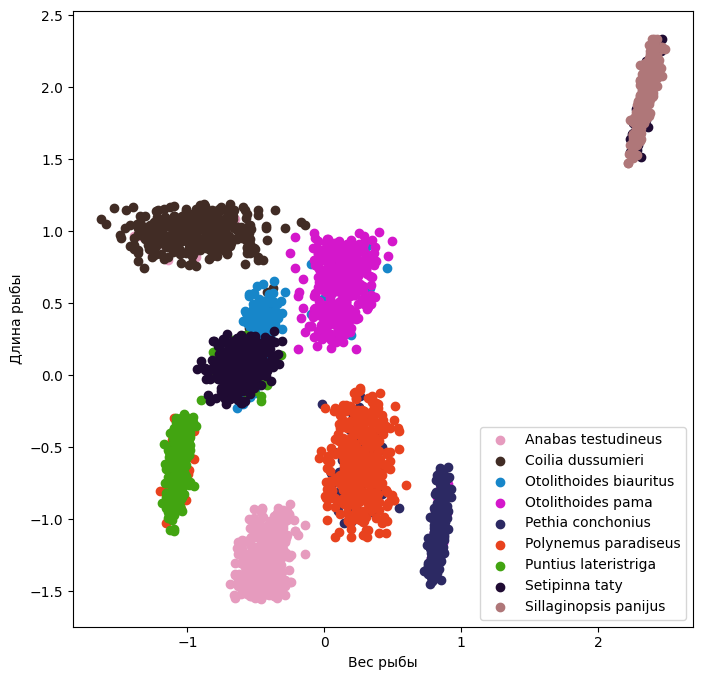

In [ ]:
plt.figure(figsize=(8,8))
r = lambda: random.randint(0, 255)
colors = ['#%02X%02X%02X' % (r(), r(), r()) for i in range(len(names))]
for i in range(len(names)):
  temp = X_vis.query(f'species == {names[i][1]}')
  plt.scatter(temp['weight'], temp['length'], label = names[i][0], c=colors[i])
plt.xlabel('Вес рыбы')
plt.ylabel('Длина рыбы')
plt.legend(loc='best')

# K-means

In [ ]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(data)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_
print(labels)

[0 0 0 ... 1 1 1]


# Иерархическая кластеризация

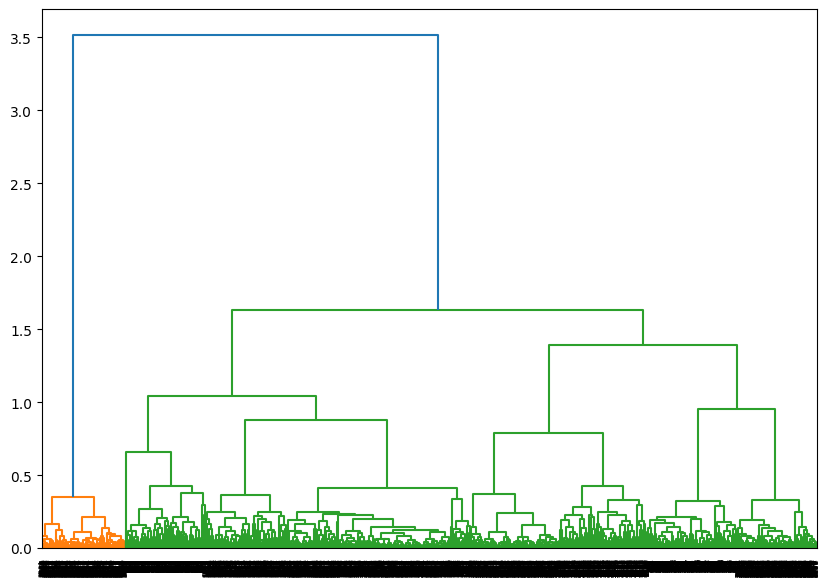

In [ ]:
Z = linkage(X, method='average')
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.show()

# Алгоритм DBSCAN

In [ ]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan.fit(X)
labels = dbscan.labels_
print(labels)

[0 0 0 ... 1 1 1]


# Метод локтя

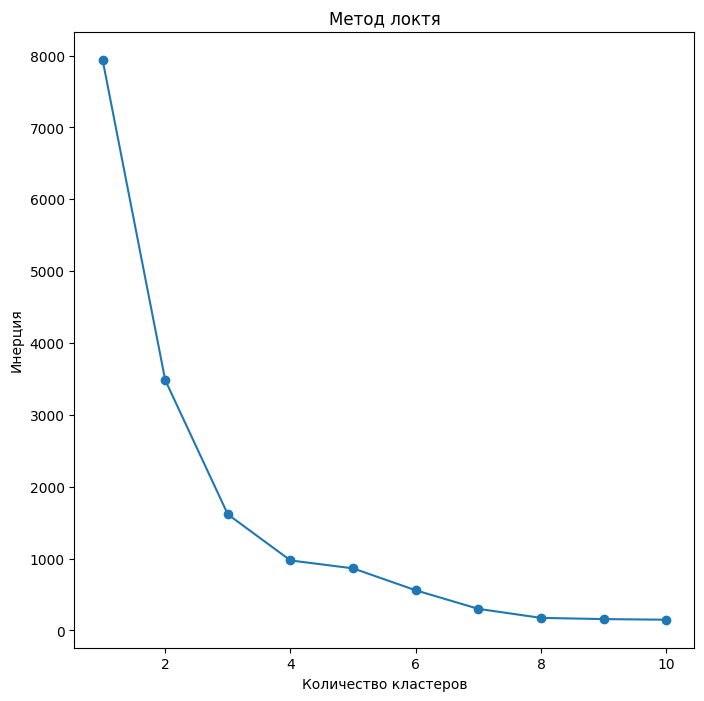

In [ ]:
inertia = []
for k in range(1, 11):
  kmeans = KMeans(n_clusters=k)
  kmeans.fit(X)
  inertia.append(kmeans.inertia_)
plt.figure(figsize=(8, 8))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Метод локтя')
plt.xlabel('Количество кластеров')
plt.ylabel('Инерция')
plt.show()

# Коэффициент силуета

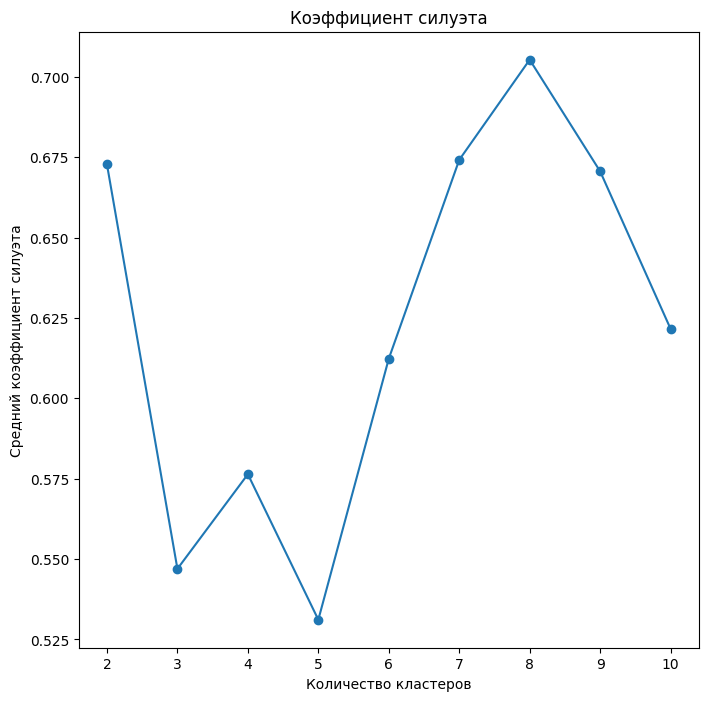

In [ ]:
silhouette_scores = []
for k in range(2, 11):
  kmeans = KMeans(n_clusters=k)
  kmeans.fit(X)
  labels = kmeans.labels_
  silhouette_scores.append(silhouette_score(X, labels))
plt.figure(figsize=(8, 8))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Коэффициент силуэта')
plt.xlabel('Количество кластеров')
plt.ylabel('Средний коэффициент силуэта')
plt.show()

# Построение дендограммы

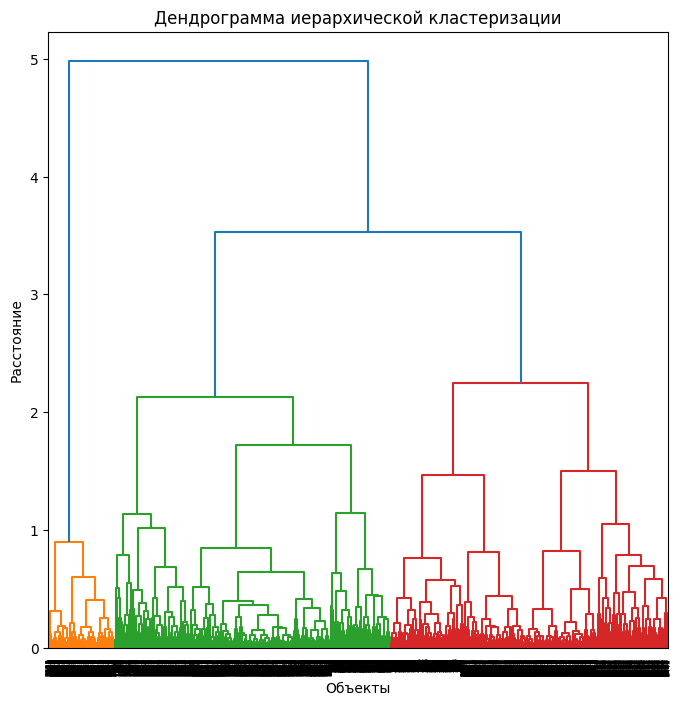

In [ ]:
Z = linkage(X, method='complete')
plt.figure(figsize=(8, 8))
dendrogram(Z)
plt.title('Дендрограмма иерархической кластеризации')
plt.xlabel('Объекты')
plt.ylabel('Расстояние')
plt.show()

# Построение графиков

## K-means

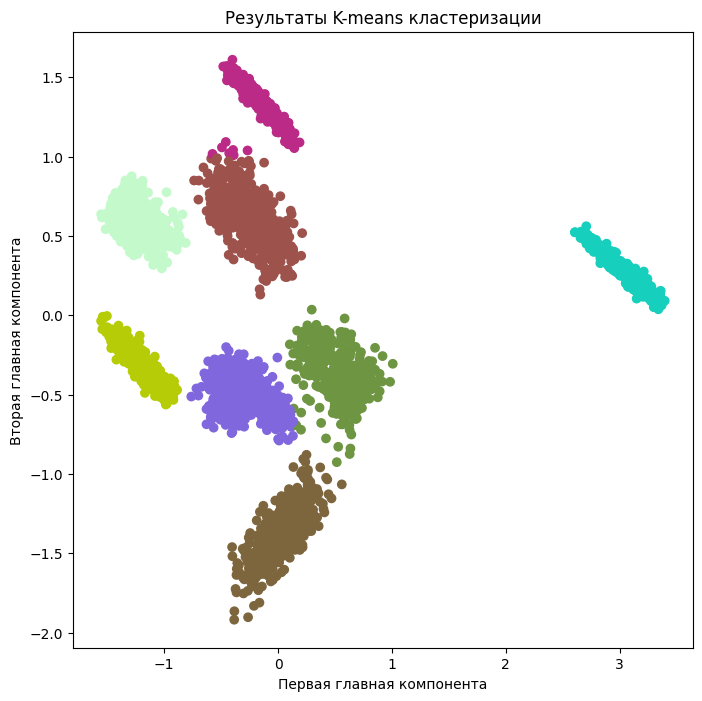

In [ ]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X)
kmeans = KMeans(n_clusters=8)
kmeans.fit(X)
labels = kmeans.labels_
names = np.unique(kmeans.labels_)
plt.figure(figsize=(8, 8))
r = lambda: random.randint(0, 255)
colors = ['#%02X%02X%02X' % (r(), r(), r()) for i in range(len(names))]
temp_df = pd.DataFrame({'labels':labels,'PCA1':pca_data[:, 0], 'PCA2':pca_data[:, 1],\
                        'colors': [colors[i%len(names)] for i in labels]})
plt.scatter(temp_df['PCA1'], temp_df['PCA2'], c=temp_df['colors'], marker='o')
plt.title('Результаты K-means кластеризации')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.show()

## Иерархическая кластериация

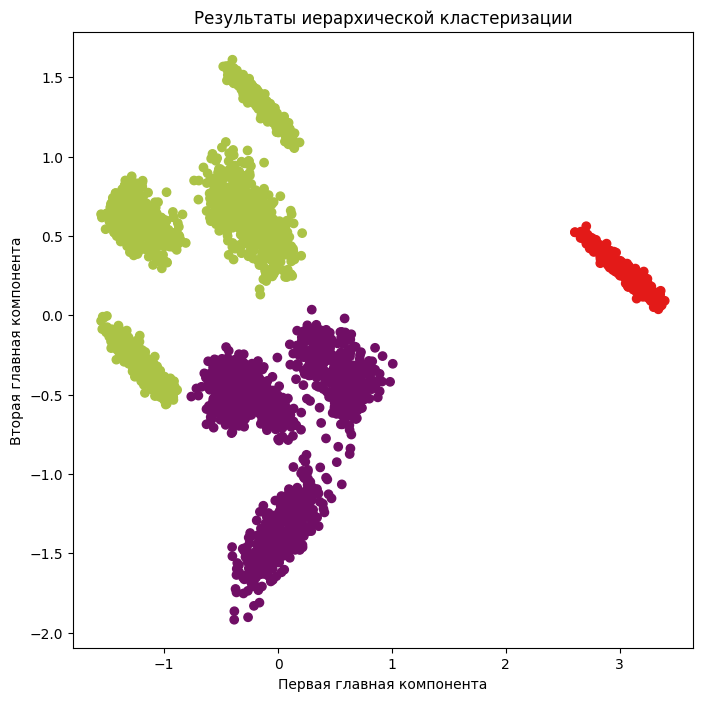

In [ ]:
from scipy.cluster.hierarchy import fcluster
clusters = fcluster(Z, 3, criterion='maxclust')
names = np.unique(clusters)
plt.figure(figsize=(8, 8))
colors = ['#%02X%02X%02X' % (r(), r(), r()) for i in range(len(names))]
temp_df = pd.DataFrame({'labels':clusters,'PCA1':pca_data[:, 0], 'PCA2':pca_data[:, 1],\
                        'colors': [colors[i%len(names)] for i in clusters]})
plt.scatter(temp_df['PCA1'], temp_df['PCA2'], c=temp_df['colors'], marker='o')
plt.title('Результаты иерархической кластеризации')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.show()

## DBSCAN

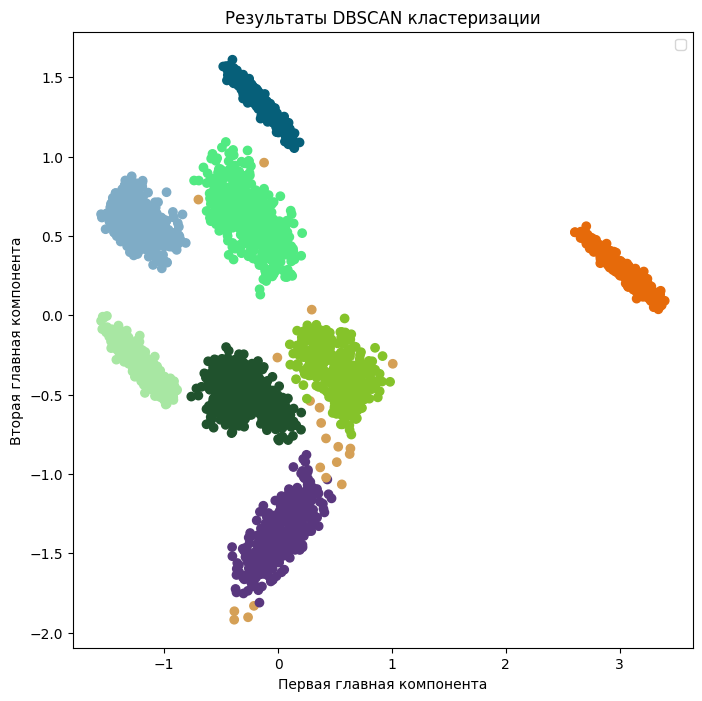

In [ ]:
dbscan = DBSCAN(eps=0.1, min_samples=5)
dbscan.fit(X)
labels = dbscan.labels_
names = np.unique(dbscan.labels_)
plt.figure(figsize=(8, 8))
colors = ['#%02X%02X%02X' % (r(), r(), r()) for i in range(len(names))]
temp_df = pd.DataFrame({'labels':labels,'PCA1':pca_data[:, 0], 'PCA2':pca_data[:, 1],\
                        'colors': [colors[i%len(names)] for i in labels]})
plt.scatter(temp_df['PCA1'], temp_df['PCA2'], c=temp_df['colors'], marker='o')
plt.title('Результаты DBSCAN кластеризации')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.show()

# Метрики

In [ ]:
# Для K-means
kmeans = KMeans(n_clusters=8)
kmeans.fit(X)
kmeans_labels = kmeans.labels_
kmeans_silhouette = silhouette_score(X, kmeans_labels)
# Для иерархической кластеризации
from scipy.cluster.hierarchy import fcluster
hierarchical_labels = fcluster(Z, 3, criterion='maxclust')
hierarchical_silhouette = silhouette_score(X,
hierarchical_labels)# Для DBSCAN
dbscan = DBSCAN(eps=0.1, min_samples=5)
dbscan.fit(X)
dbscan_labels = dbscan.labels_
dbscan_silhouette = silhouette_score(X, dbscan_labels)
# Вывод средних коэффициентов силуэта для каждого алгоритма
print(f"K-means silhouette: {kmeans_silhouette}")
print(f"Hierarchical silhouette: {hierarchical_silhouette}")
print(f"DBSCAN silhouette: {dbscan_silhouette}")

K-means silhouette: 0.7053701743032269
Hierarchical silhouette: 0.5204003770157668
DBSCAN silhouette: 0.698760575204516


In [ ]:
for i in range(1,11):
  dbscan = DBSCAN(eps=i/10, min_samples=5)
  dbscan.fit(X)
  dbscan_silhouette = silhouette_score(X, dbscan.labels_)
  print(f"Silhouette for DBSCAN with eps={i/10}: {dbscan_silhouette}")

Silhouette for DBSCAN with eps=0.1: 0.698760575204516
Silhouette for DBSCAN with eps=0.2: 0.4964226389439392
Silhouette for DBSCAN with eps=0.3: 0.6727848531409395
Silhouette for DBSCAN with eps=0.4: 0.6727848531409395
Silhouette for DBSCAN with eps=0.5: 0.6727848531409395
Silhouette for DBSCAN with eps=0.6: 0.6727848531409395
Silhouette for DBSCAN with eps=0.7: 0.6727848531409395
Silhouette for DBSCAN with eps=0.8: 0.6727848531409395
Silhouette for DBSCAN with eps=0.9: 0.6727848531409395
Silhouette for DBSCAN with eps=1.0: 0.6727848531409395


In [ ]:
import math

def ReLU(x):
    return max(0, x)

def dReLU(x):
    if x > 0:
        return 1
    return 0

# Tanh activation
t1 =round((1 - math.tanh(math.tanh(math.tanh(math.tanh(100)))) ** 2) * (1 - math.tanh(math.tanh(math.tanh(100))) ** 2)
          * (1 - math.tanh(math.tanh(100)) ** 2) * (1 - math.tanh(100) ** 2) * 100, 3)
t2 = round((1 - math.tanh(math.tanh(math.tanh(math.tanh(100)))) ** 2) * (1 - math.tanh(math.tanh(math.tanh(100))) ** 2)
           * (1 - math.tanh(math.tanh(100)) ** 2) * math.tanh(100), 3)
t3 = round((1 - math.tanh(math.tanh(math.tanh(math.tanh(100)))) ** 2) * (1 - math.tanh(math.tanh(math.tanh(100))) ** 2)
      * math.tanh(math.tanh(100)), 3)
t4 = round((1 - math.tanh(math.tanh(math.tanh(math.tanh(100)))) ** 2) * math.tanh(math.tanh(math.tanh(100))), 3)
# ReLU activation
r1 = round(dReLU(ReLU(ReLU(ReLU(100)))) * dReLU(ReLU(ReLU(100))) * dReLU(ReLU(100)) * dReLU(100) * 100, 3)
r2 = round(dReLU(ReLU(ReLU(ReLU(100)))) * dReLU(ReLU(ReLU(100))) * dReLU(ReLU(100)) * ReLU(100), 3)
r3 = round(dReLU(ReLU(ReLU(ReLU(100)))) * dReLU(ReLU(ReLU(100))) * ReLU(ReLU(100)), 3)
r4 = round(dReLU(ReLU(ReLU(ReLU(100)))) * ReLU(ReLU(ReLU(100))), 3)
answer1, answer2 = [t1, t2, t3, t4], [r1, r2, r3, r4]

print(answer1, answer2, sep=',')

[0.0, 0.168, 0.304, 0.436],[100, 100, 100, 100]
